# Compound Interest Simulator | Educational Notebook

_By:_
- _José Reyes_
- _LinkedIn: /ln/arkreyes_
- _Youtube Channel (Spanish Content) : @arkreyes_
- _Twitter : @aarkreyes_

## Introduction

Compound interest is one of the most important concepts in finance and investing.

Unlike simple interest, compound interest allows investment returns to generate additional returns over time. This creates exponential growth.

This notebook explores:

- How compound interest works.
- How monthly contributions accelerate investment growth.
- How to simulate investment growth using Python.
- How to visualize long-term financial growth using NumPy and Pandas.

# Financial Theory

## What is Compound Interest?

Compound interest is the process where an investment earns returns not only on the initial principal, but also on accumulated returns from previous periods.

In simple terms:

    Your money starts generating money.

Over long periods of time, this creates **exponential growth**.

## Compound Interest Formula

The Compound Interest (Annual Compounding) is:

$$A = P\left(1 + r\right)^{t}$$

Where:

- $A$ = Final investment value.
- $P$ = Initial investment (principal).
- $r$ = Annual interest rate.
- $t$ = Number of years.

**_This formula is used when interest is capitalized ONCE per year_**

Use Scenarios:

- Annual Investments.
- Fast Estimations.
- Simplified Models.
- Annual bonuses.
- Conservative Investments.

The Compound Interest with Periodic Compounding is:

$$A = P\left(1 + \frac{r}{n}\right)^{nt}$$

Where:

- $A$ = Final investment value.
- $P$ = Initial investment (principal).
- $r$ = Annual interest rate.
- $n$ = Number of compounding periods per year (1 = annual, 5 = bimonthly, 4 = trimonthly, 12 = monthly, 365 = daily).
- $t$ = Number of years.

**_This formula is used when interest is capitalized MULTIPLE TIMES per year (monthly, bimonthly, quarterly)_**

Use Scenarios:

- Savings Accounts (NU, Revolut...)
- ETFs
- Mortage Loans

## Why This Formula Matters

This formula is widely used in:
- Investment analysis.
- Retirement planning.
- Savings accounts.
- Index fund projections.
- Portfolio growth estimation.
- Financial forecasting.

## Real-World Example

Suppose:

- Initial investment: $10,000
- Annual return: 8%
- Monthly compounding
- Investment duration: 20 years

The formula estimates how much the investment could grow over time.

# Python Setup

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Sample Dataset Using Pandas

Instead of testing only one scenario, we can create a small dataset with different investment profiles.

In [62]:
sample_data = {
    'Investor': ['Conservative', 'Balanced', 'Aggressive'],
    'Initial_Investment': [5000, 10000, 15000],
    'Monthly_Contribution': [200, 500, 800],
    'Annual_Return': [0.05, 0.08, 0.12],
    'Years': [10, 20, 25]
}

In [63]:
investments_df = pd.DataFrame(sample_data)

In [64]:
investments_df

,Investor,Initial_Investment,Monthly_Contribution,Annual_Return,Years
0,Conservative,5000,200,0.05,10
1,Balanced,10000,500,0.08,20
2,Aggressive,15000,800,0.12,25


## Applying the Basic Compound Interest Formula

We can now calculate the future value of each investment scenario.

For simplicity, we will first ignore monthly contributions.

In [75]:
def basic_compound_interest(principal, annual_rate, years, compounds_per_year=12):
    return principal * (1 + annual_rate) ** (years)

## Testing the Formula

In [66]:
investments_df['Future_Value'] = investments_df.apply(
    lambda row: basic_compound_interest(
        row['Initial_Investment'],
        row['Annual_Return'],
        row['Years']
    ),
    axis=1
)

In [67]:
investments_df

,Investor,Initial_Investment,Monthly_Contribution,Annual_Return,Years,Future_Value
0,Conservative,5000,200,0.05,10,8144.473134
1,Balanced,10000,500,0.08,20,46609.571438
2,Aggressive,15000,800,0.12,25,255000.966100


## Understanding the Results

The output shows how different interest rates and investment durations affect long-term growth.

Important observations:

- Higher annual returns create dramatically larger outcomes.
- Time has a massive impact due to exponential growth.
- Even small initial investments can grow substantially over decades.

We can simulate how the investment grows over time.

In [68]:
# Simple compound interest calculation for a single investment

# Defininf the parameters for the compound interest calculation
principal = 10000
annual_rate = 0.08
years = 20
months = years * 12

# Compount interest calculation
monthly_rate = annual_rate / 12

balances = np.zeros(months) # Initialize an array to store the balance for each month
balances[0] = principal # Set the initial balance to the principal amount

# Calculate the balance for each month using the compound interest formula
for month in range(1, months):
    balances[month] = balances[month - 1] * (1 + monthly_rate)

In [69]:
pd.DataFrame(balances, columns=['Balance'])

,Balance
0,10000.000000
1,10066.666667
2,10133.777778
3,10201.336296
4,10269.345205
...,...
235,47658.101273
236,47975.821949
237,48295.660762
238,48617.631833


## Plotting the Growth Curve

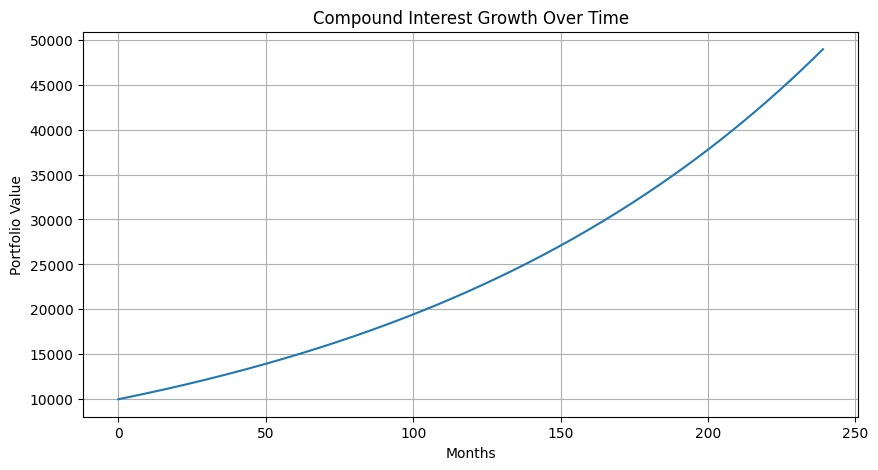

In [70]:
# Graph the growth of the investment over time

plt.figure(figsize=(10, 5))
plt.plot(balances)
plt.title('Compound Interest Growth Over Time')
plt.xlabel('Months')
plt.ylabel('Portfolio Value')
plt.grid(True)
plt.show()

## Plotting Growth for Year

In [71]:
balances_df = pd.DataFrame(balances, columns=['Balance'])
balances_df['Month'] = balances_df.index + 1
balances_df['Year'] = (balances_df['Month'] - 1) // 12 + 1

In [72]:
balances_df

,Balance,Month,Year
0,10000.000000,1,1
1,10066.666667,2,1
2,10133.777778,3,1
3,10201.336296,4,1
4,10269.345205,5,1
...,...,...,...
235,47658.101273,236,20
236,47975.821949,237,20
237,48295.660762,238,20
238,48617.631833,239,20


In [73]:
yearly_interest = balances_df.groupby('Year')['Balance'].last().reset_index()

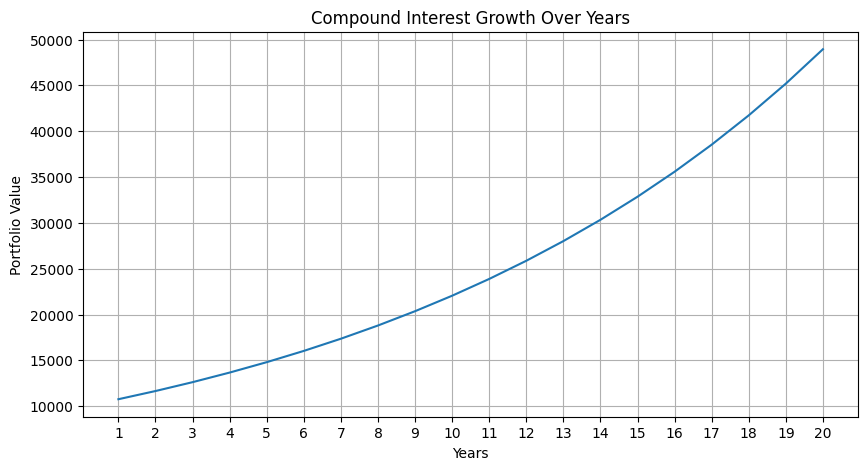

In [74]:
# Graph the yearly interest growth

plt.figure(figsize=(10, 5))
plt.plot(yearly_interest['Year'], yearly_interest['Balance'])
plt.title('Compound Interest Growth Over Years')
plt.xlabel('Years')
plt.ylabel('Portfolio Value')
plt.xticks(yearly_interest['Year'])
plt.grid(True)
plt.show()

# Key Financial Insights

## 1. Time is extremely powerful

The longer money remains invested, the stronger compounding becomes.

## 2. Consistency matters more than large initial capital

Small monthly contributions create substantial long-term results.

## 3. Higher returns dramatically increase future value

Small differences in annual returns produce massive differences over decades.

# Conclusion

This notebook demonstrated:

- The mathematics behind compound interest
- Financial growth simulation using NumPy
- Scenario analysis using Pandas
- Investment visualization with Matplotlib

Compound interest is one of the foundational concepts in quantitative finance and long-term investing.

# BONUS

## [ SIMULATION ] - Compound Interest with Recurring Deposits

This iterative model simulates real-world investing behavior by applying compound growth to the current portfolio balance and then adding a recurring monthly contribution. Unlike the closed-form compound interest equation, this approach allows dynamic cash flows and more realistic financial simulations.

$$ Balance_t = Balance_{t-1}(1 + r_m) + C $$

Where:

- $r_m$ : Monthly Rate.
- $C$ : Monthly Contribution.

Explicit version of the formula for this simulated case:

$$ Portfolio_t = Portfolio_{t-1}(1 + r_m) + MonthlyContribution $$

This simulation will have:

- Initial invest of 10000 dollars.
- Monthly deposits of 100 dollars.
- Monthly compound interest.
- Simulation of 20 years.

### Python Simulation

In [76]:
import numpy as np
import pandas as pd

In [77]:
# Parameters

initial_investment = 10000
monthly_contribution = 100
annual_rate = 0.08
years = 20

In [78]:
# Time settings

months = years * 12
monthly_rate = annual_rate / 12

In [79]:
# Arrays

balances = np.zeros(months)
contributions = np.zeros(months)

In [80]:
# Initial values

balances[0] = initial_investment
contributions[0] = initial_investment

In [81]:
# Simulation (Formula applied iteratively)

for month in range(1, months):

    balances[month] = (
        balances[month - 1] * (1 + monthly_rate)
        + monthly_contribution
    )

    contributions[month] = (
        contributions[month - 1]
        + monthly_contribution
    )

In [82]:
# Creating DataFrame

simulation_df = pd.DataFrame({
    'month' : np.arange(1, months + 1),
    'portfolio_value' : balances,
    'total_contributions' : contributions
})

In [83]:
# Creating 'year' column

simulation_df['year'] = ((simulation_df['month'] - 1) // 12) + 1

In [84]:
# Compound growth generated

simulation_df['investment_growth'] = (
    simulation_df['portfolio_value']
    - simulation_df['total_contributions']
)

In [85]:
simulation_df

,month,portfolio_value,total_contributions,year,investment_growth
0,1,10000.000000,10000.0,1,0.000000
1,2,10166.666667,10100.0,1,66.666667
2,3,10334.444444,10200.0,1,134.444444
3,4,10503.340741,10300.0,1,203.340741
4,5,10673.363012,10400.0,1,273.363012
...,...,...,...,...,...
235,236,104145.253184,33500.0,20,70645.253184
236,237,104939.554872,33600.0,20,71339.554872
237,238,105739.151904,33700.0,20,72039.151904
238,239,106544.079583,33800.0,20,72744.079583


In [86]:
# Creating the yearly summary DataFrame

yearly_summary = simulation_df.groupby('year').last().reset_index()

In [87]:
yearly_summary

,year,month,portfolio_value,total_contributions,investment_growth
0,1,12,11895.683116,11100.0,795.683116
1,2,24,14128.011550,12300.0,1828.011550
2,3,36,16545.622143,13500.0,3045.622143
3,4,48,19163.893223,14700.0,4463.893223
4,5,60,21999.479511,15900.0,6099.479511
5,6,72,25070.418062,17100.0,7970.418062
6,7,84,28396.242999,18300.0,10096.242999
7,8,96,31998.109765,19500.0,12498.109765
8,9,108,35898.929697,20700.0,15198.929697
9,10,120,40123.515759,21900.0,18223.515759


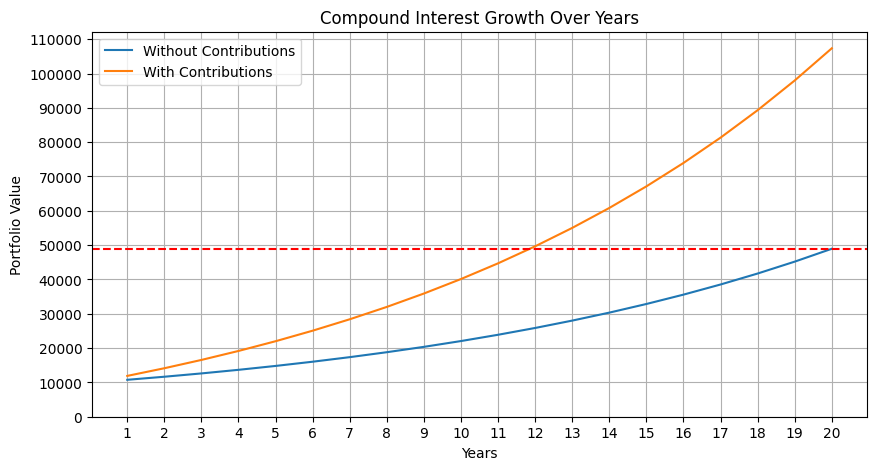

In [88]:
# Graph the yearly interest growth with compound growth and contributions vs the simple compound growth without contributions

plt.figure(figsize=(10, 5))

plt.plot(yearly_interest['Year'], yearly_interest['Balance'], label='Without Contributions')
plt.plot(yearly_summary['year'], yearly_summary['portfolio_value'], label='With Contributions')

plt.title('Compound Interest Growth Over Years')

plt.xlabel('Years')
plt.ylabel('Portfolio Value')

plt.xticks(yearly_interest['Year'])
plt.yticks(np.arange(0, yearly_summary['portfolio_value'].max() + 10000, 10000))
plt.axhline(y=yearly_interest['Balance'].max(), color='r', linestyle='--')

plt.grid(True)
plt.legend()
plt.show()